# Visualization Session 6

July 10th, 2025

# Seaborn

In [2]:
# import libraries and packages
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

np.random.seed(613)

In [3]:
# load tips sample dataset

tips = sns.load_dataset('tips')
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

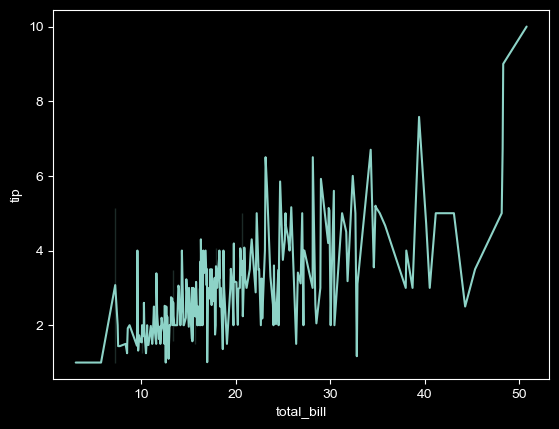

In [10]:
# set dark mode - LEARNING SUPPORT, if you're reading this, I did play around with sns.set_style but seaborn does not have a nice dark mode and I use dark mode for accessibility purposes, so I stuck with the plt one
plt.style.use('dark_background')



# create basic plot

sns.lineplot(data= tips, # choose dataset
             x= 'total_bill', #choose x variable
             y= 'tip') #choose y variable



[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

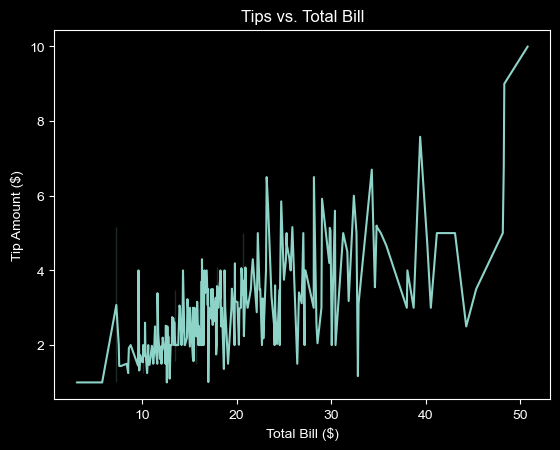

In [11]:
# add title and axis labels

tipgraph = sns.lineplot(data=tips,
                        x= 'total_bill',
                        y= 'tip')

tipgraph.set(title= 'Tips vs. Total Bill',
             xlabel= 'Total Bill ($)',
             ylabel= 'Tip Amount ($)')



[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

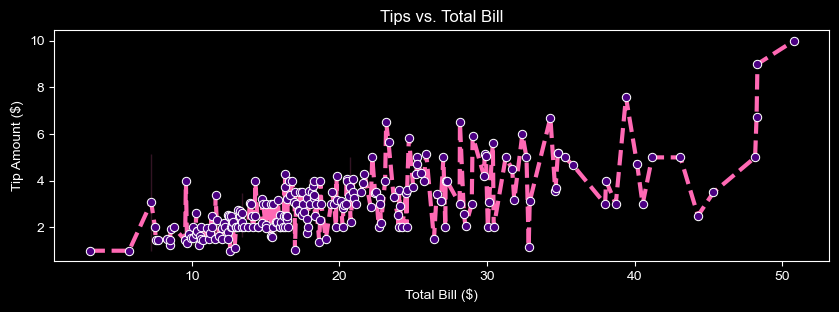

In [13]:
# change figure size

fig = plt.subplots(figsize = (10,3))

tipgraph = sns.lineplot(data=tips,
                        x= 'total_bill',
                        y= 'tip',
                        color= 'hotpink',
                        linestyle= '--',
                        linewidth= 3,
                        marker= 'o',
                        markerfacecolor = 'indigo')

tipgraph.set(title= 'Tips vs. Total Bill',
             xlabel= 'Total Bill ($)',
             ylabel= 'Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

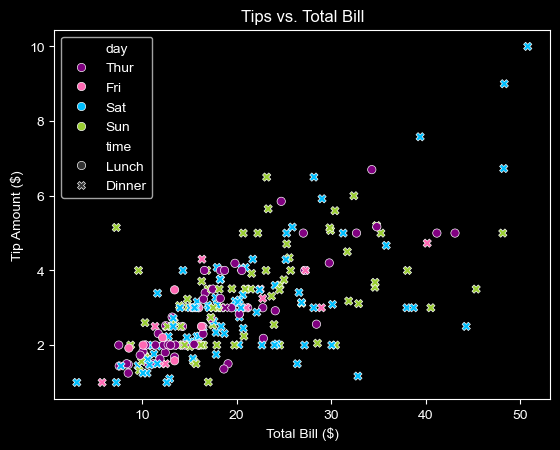

In [ ]:
# adding multiple variables

tipgraph = sns.scatterplot(data= tips,
                           x= 'total_bill',
                           y= 'tip',
                           style = 'time', # set marker style according to time column
                           hue = 'day', # set market hue according to day column, using the palette below
                           palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])

tipgraph.set(title= 'Tips vs. Total Bill',
             xlabel= 'Total Bill ($)',
             ylabel= 'Tip Amount ($)')

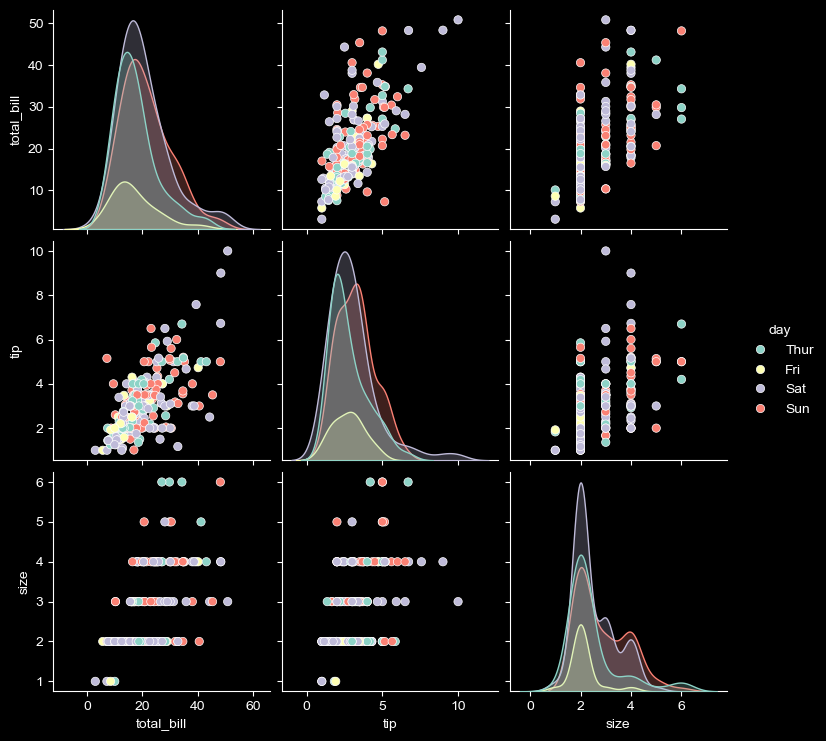

In [15]:
# using pairplot() to compare variables

sns.pairplot(data= tips,
             hue = 'day')

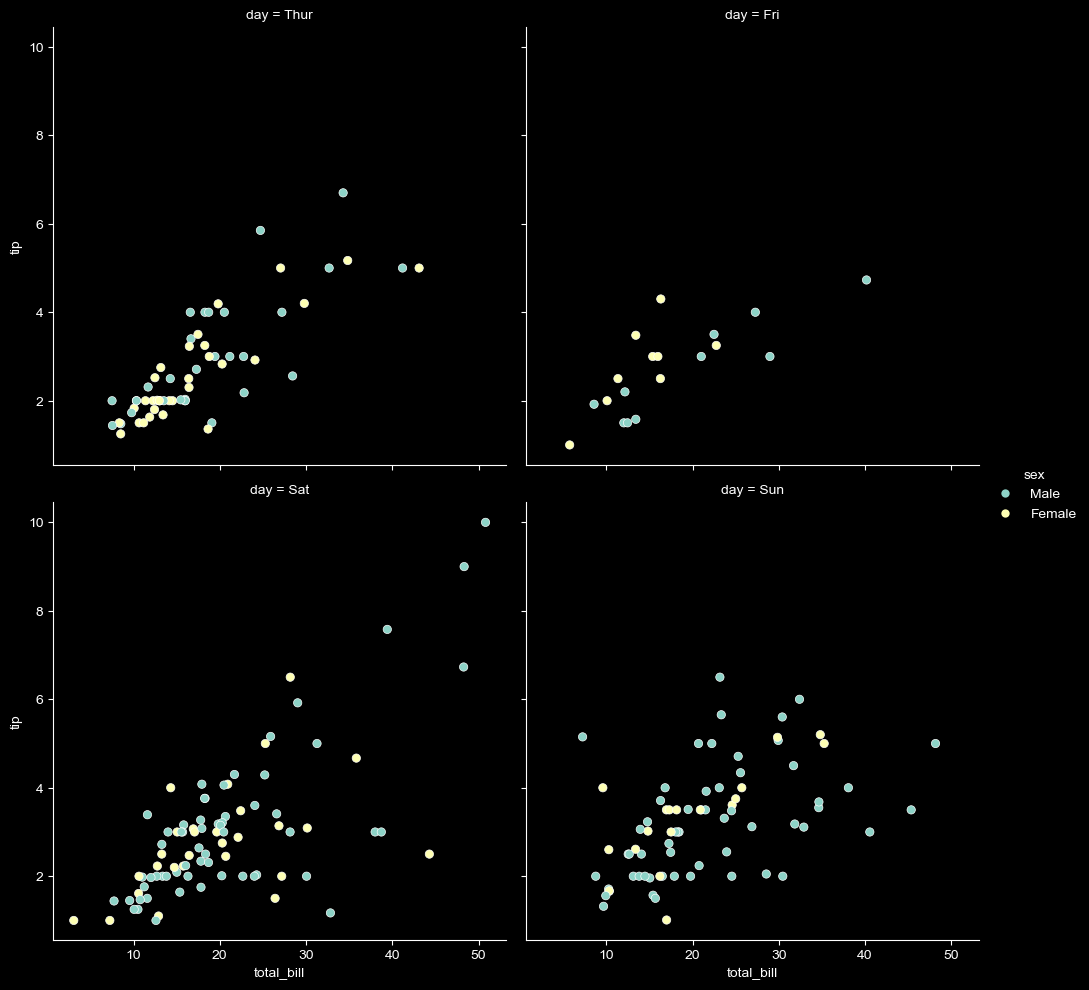

In [ ]:
# using relplot() to explore specific levels within variables

daysplot = sns.relplot(data= tips, #set data as tips data
                       x= 'total_bill', #set x variable
                       y= 'tip', #set y variable
                       hue= 'sex', #set hue to sex variable
                       col= 'day', # set each axis to different values of day
                       kind= 'scatter', # set plot type to scatter
                       col_wrap= 2) # set number of columns before wrap

# Plotly

In [18]:
import plotly.graph_objects as go 

# create data

x1 = np.array(['Luffy', 'Zoro', 'Nami', ' Usopp', 'Sanji'])
y1 = np.array([110,180,240,99,220])

In [20]:
# making our plot

graph = go.Figure()

# choose bar graph and data
graph.add_trace(go.Bar(x=x1, y=y1)) # trace is analogous to ax in plt

# add titles and set to dark mode
graph.update_layout(title= 'Pirate Scores',
                    xaxis_title = 'Pirates',
                    yaxis_title= 'Score',
                    template= 'plotly_dark')

#show plot
graph.show()

In [24]:
# customizing graph

graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1,
                           mode= 'markers', # points for a scatter ploy
                           marker=dict(
                               size=15, #point size
                               color='hotpink', # point colour
                               opacity=1, #point transparency/alpha
                               line=dict(width=5, color= 'purple') #point outline
                           )))

graph.update_layout(title = 'Interactive Pirate Plot',
                    xaxis_title= 'Pirates',
                    yaxis_title= 'Scores',
                    width=500,
                    height=500,
                    template='plotly_dark')

# Wordclouds and venn diagrams

In [26]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [27]:
# import package
from wordcloud import WordCloud

df = pd.read_csv('https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv',
                 on_bad_lines='skip')

df
                 

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(-0.5, 399.5, 199.5, -0.5)

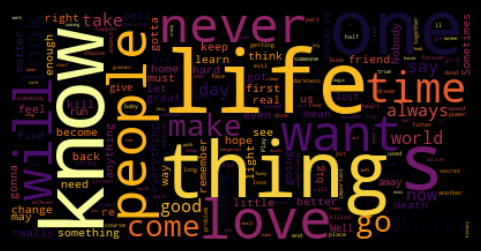

In [30]:
# join all our text from each row from our quote column into a string

text= " ".join(each for each in df.quote) # in each quote join words separated with a space

# generate our wordcloud image

wordcloud = WordCloud(background_color = 'black', colormap= 'inferno').generate(text) # black for accessibility for me

# use matplotlib syntax to put our image in a figure

fig, ax = plt.subplots(figsize = (7,3))
ax.imshow(wordcloud,  # imshow() to show images in axes
          interpolation= 'bilinear') # this line helps smooth our image
ax.axis('off')

In [33]:
pip install matplotlib_venn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib_venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45437 sha256=a56aae2cb1af5788880e5d3da47a374e2a0a302b91e53b7b24e903cd117a9e32
  Stored in directory: c:\users\tsuit\appdata\local\pip\cache\wheels\86\29\d8\0f3c5a37c967a34fb40aaabd414f92104d2ad5fb149c0114a1
Successfully built matplotlib_venn
Note: you may need to restart the kernel to use updated packages.


In [34]:
# Venn Diagrams

#import extension
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [35]:
# define our sets

A = set(['apple', 'banana', 'watermelon'])
B = set(['pumpkin', 'blueberry', 'apple', 'key lime'])

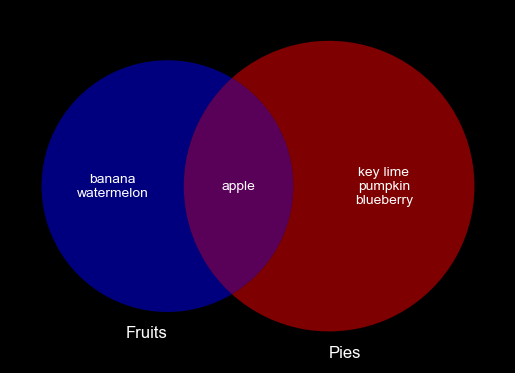

In [ ]:
# create diagram

diagram = venn2([A,B],
                set_labels = ('Fruits', 'Pies'),
                set_colors = ('blue', 'red'),
                alpha = 0.5) # opacity

# show text in diagram

diagram.get_label_by_id('10').set_text('\n'.join(A - B)) # left circle
diagram.get_label_by_id('11').set_text('\n'.join(A & B)) # middle slice
diagram.get_label_by_id('01').set_text('\n'.join(B - A)) # right circle

# id is not ten, eleven, and 1. It's 1 and 0, 1 and 1, and 0 and 1, as in present in left but not right, present in left and right, and present in right but not left, respectively.
# '\n' is so that it creates a new line when joining words